# **3. Classification of natural disaster Tweets: Training**

The dataset used in this project comes from the Disaster Tweets dataset, which contains a collection of tweets labeled according to whether they refer to a real disaster event or not. The goal of the dataset is to support the development of machine learning models capable of automatically identifying disaster-related information from social media posts.

In natural language processing tasks, raw text data often contains noise such as punctuation, links, mentions, and other elements that may not contribute meaningful information for machine learning models. Therefore, applying different **text preprocessing strategies** can help improve model performance by standardizing and simplifying the textual input.

In this project, three different preprocessing configurations were implemented and compared to evaluate their impact on the classification performance.



## 0. Imports

In [1]:
import re
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.metrics import f1_score, accuracy_score, precision_score, recall_score, confusion_matrix, classification_report
from sklearn.model_selection import train_test_split
from tensorflow.keras import models
from tensorflow.keras import layers
from tensorflow.keras import optimizers
import numpy as np
import sys
import os
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tensorflow as tf
import time
import json
from IPython.display import display, HTML
from datetime import datetime
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
from IPython.display import display


## 1. Load dataset

In [2]:
path1 = 'Configurations_Data/cleaned_data_conf1.csv'
path2 = 'Configurations_Data/cleaned_data_conf2.csv'
path3 = 'Configurations_Data/cleaned_data_conf3.csv'

In [3]:
df1 = pd.read_csv(path1)
df2 = pd.read_csv(path2)
df3 = pd.read_csv(path3)


## 2. Preprocessing Data

In [4]:
y1 = df1['target']
x1 = df1.drop('target', axis=1)

y2 = df2['target']
x2 = df2.drop('target', axis=1)

y3 = df3['target']
x3 = df3.drop('target', axis=1)

In [5]:
vectorizer1 = TfidfVectorizer()
vectorizer2 = TfidfVectorizer()
vectorizer3 = TfidfVectorizer()

x1 = vectorizer1.fit_transform(x1['text'])
x2 = vectorizer2.fit_transform(x2['text'])
x3 = vectorizer3.fit_transform(x3['text'])

y1 = y1.to_numpy()
y2 = y2.to_numpy()
y3 = y3.to_numpy()

In [6]:
x1 = x1.toarray()
x2 = x2.toarray()
x3 = x3.toarray()

## 2. Divide Data

In [7]:
x1_train, x1_test, y1_train, y1_test = train_test_split(x1, y1, test_size=0.2, random_state=42)
x2_train, x2_test, y2_train, y2_test = train_test_split(x2, y2, test_size=0.2, random_state=42)
x3_train, x3_test, y3_train, y3_test = train_test_split(x3, y3, test_size=0.2, random_state=42)

x1_val, x1_test, y1_val, y1_test = train_test_split(x1_test, y1_test, test_size=0.5, random_state=42)
x2_val, x2_test, y2_val, y2_test = train_test_split(x2_test, y2_test, test_size=0.5, random_state=42)
x3_val, x3_test, y3_val, y3_test = train_test_split(x3_test, y3_test, test_size=0.5, random_state=42)

In [8]:
print(f"Configuration 1: Train set: {(x1_train).shape}, Validation set: {(x1_val).shape}, Test set: {(x1_test).shape}")
print(f"Configuration 2: Train set: {(x2_train).shape}, Validation set: {(x2_val).shape}, Test set: {(x2_test).shape}")
print(f"Configuration 3: Train set: {(x3_train).shape}, Validation set: {(x3_val).shape}, Test set: {(x3_test).shape}")


Configuration 1: Train set: (6041, 14617), Validation set: (755, 14617), Test set: (756, 14617)
Configuration 2: Train set: (6041, 14491), Validation set: (755, 14491), Test set: (756, 14491)
Configuration 3: Train set: (6041, 13316), Validation set: (755, 13316), Test set: (756, 13316)


**Auxiliar functions**

In [9]:
def metrics(y_true, y_pred):
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred)
    rec = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)

    print("Accuracy:", accuracy_score(y_true, y_pred))
    print("Precision:", precision_score(y_true, y_pred))
    print("Recall:", recall_score(y_true, y_pred))
    print("F1 Score:", f1_score(y_true, y_pred))

    print("\nConfusion Matrix:")
    print(confusion_matrix(y_true, y_pred))

    print("\nClassification Report:")
    print(classification_report(y_true, y_pred))
    return acc, prec, rec, f1


def html_metrics(y_true, y_pred):
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred)
    rec = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    auc = tf.keras.metrics.AUC()(y_true, y_pred).numpy()

    display(HTML(f"""
    <div style="
    background-color:#ffe6f2;
    padding:15px;
    border-radius:10px;
    font-family:Arial;
    width:400px">
    <h3 style="color:#d63384;"> Model Metrics </h3>
    <p><b>Accuracy:</b> {acc:.3f}</p>
    <p><b>Precision:</b> {prec:.3f}</p>
    <p><b>Recall:</b> {rec:.3f}</p>
    <p><b>F1 Score:</b> {f1:.3f}</p>
    <p><b>AUC:</b> {auc:.3f}</p>
    </div>
    """))
    return acc, prec, rec, f1, auc


def confusion_matrix_heatmap(y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(5,4))
    sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap="pink",
            xticklabels=["Not Disaster", "Disaster"],
            yticklabels=["Not Disaster", "Disaster"])

    plt.title("Confusion Matrix", fontsize=14)
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.show()


In [10]:
def metrics_report(y_true, y_pred):
    report = classification_report(y_true, y_pred, output_dict=True)
    df_report = pd.DataFrame(report).transpose()
    return df_report.style.background_gradient(cmap="RdPu")


In [11]:
def save_metrics(model_name, configuration, acc, prec, rec, f1, auc):
    save_dir_path = "model_metrics"
    
    metrics_dict = {"model": model_name,
        "configuration": configuration,
        "accuracy": float(acc),
        "precision": float(prec),
        "recall": float(rec),
        "f1_score": float(f1),
        "auc": float(auc),
        "timestamp": datetime.now().strftime("%Y-%m-%d %H:%M:%S")
    }

    if not os.path.exists(save_dir_path):
        os.makedirs(save_dir_path, exist_ok=True)
    file_path = os.path.join(save_dir_path, f"{model_name}_{configuration}.json")
    with open(file_path, "w") as f: json.dump(metrics_dict, f, indent=4)
    print(f"Metrics saved to: {file_path}")

## **Configuration 1 – Basic Text Cleaning**

The first configuration applies a set of basic preprocessing steps aimed at standardizing the text and removing unnecessary elements. The following operations are performed:

* Conversion of all text to **lowercase** in order to avoid treating the same word with different capitalization as different tokens.
* **Removal of URLs**, since links generally do not provide useful semantic information for the classification task.
* **Removal of mentions** (e.g., `@username`), which typically refer to users rather than meaningful textual content.
* **Removal of punctuation marks**, such as commas, periods, and special characters, to simplify the text representation.

This configuration establishes a baseline preprocessing pipeline.



In [12]:
model1 = models.Sequential()

model1.add(layers.Dense(128, activation='relu', input_shape=(x1_train.shape[1],)))
model1.add(layers.Dropout(0.5))

model1.add(layers.Dense(64, activation='relu'))
model1.add(layers.Dropout(0.3))

model1.add(layers.Dense(32, activation='relu'))
model1.add(layers.Dense(16, activation='relu'))
model1.add(layers.Dense(1, activation='sigmoid'))

In [13]:
model1.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy', 'Precision']
)

In [14]:
history1 = model1.fit(
    x1_train,
    y1_train,
    epochs=10,
    batch_size=32,
    validation_data=(x1_val, y1_val))

Epoch 1/10


189/189 [==============================] - 3s 8ms/step - loss: 0.5751 - accuracy: 0.6888 - precision: 0.7726 - val_loss: 0.4489 - val_accuracy: 0.8040 - val_precision: 0.8359
Epoch 2/10
189/189 [==============================] - 1s 7ms/step - loss: 0.3223 - accuracy: 0.8747 - precision: 0.8909 - val_loss: 0.4896 - val_accuracy: 0.7947 - val_precision: 0.8340
Epoch 3/10
189/189 [==============================] - 1s 6ms/step - loss: 0.1966 - accuracy: 0.9277 - precision: 0.9407 - val_loss: 0.5592 - val_accuracy: 0.7762 - val_precision: 0.7399
Epoch 4/10
189/189 [==============================] - 1s 6ms/step - loss: 0.1244 - accuracy: 0.9575 - precision: 0.9627 - val_loss: 0.6149 - val_accuracy: 0.7960 - val_precision: 0.7707
Epoch 5/10
189/189 [==============================] - 1s 6ms/step - loss: 0.0932 - accuracy: 0.9687 - precision: 0.9732 - val_loss: 0.7198 - val_accuracy: 0.7960 - val_precision: 0.7833
Epoch 6/10
189/189 [==============================] - 1s 6ms/step - 

In [15]:
y1_pred = model1.predict(x1_test)
y1_pred = (y1_pred > 0.5).astype(int)

24/24 [==============================] - 0s 2ms/step


In [16]:
metrics(y1_test, y1_pred)

Accuracy: 0.7724867724867724
Precision: 0.7389830508474576
Recall: 0.6964856230031949
F1 Score: 0.7171052631578947

Confusion Matrix:
[[366  77]
 [ 95 218]]

Classification Report:
              precision    recall  f1-score   support

           0       0.79      0.83      0.81       443
           1       0.74      0.70      0.72       313

    accuracy                           0.77       756
   macro avg       0.77      0.76      0.76       756
weighted avg       0.77      0.77      0.77       756



(0.7724867724867724,
 0.7389830508474576,
 0.6964856230031949,
 0.7171052631578947)

,precision,recall,f1-score,support
0,0.793926,0.826185,0.809735,443.000000
1,0.738983,0.696486,0.717105,313.000000
accuracy,0.772487,0.772487,0.772487,0.772487
macro avg,0.766455,0.761335,0.763420,756.000000
weighted avg,0.771179,0.772487,0.771384,756.000000


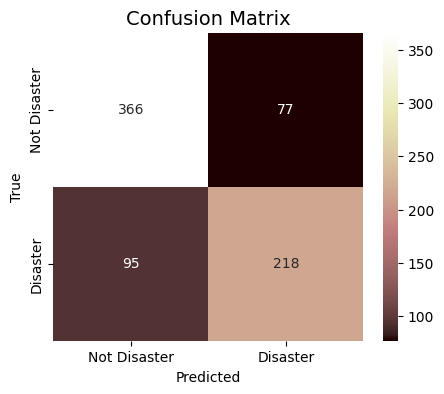

Metrics saved to: model_metrics\NN_Configuration 1.json


In [17]:
display(metrics_report(y1_test, y1_pred))
acc, prec, rec, f1, auc = html_metrics(y1_test, y1_pred)
confusion_matrix_heatmap(y1_test, y1_pred)
save_metrics("NN", "Configuration 1", acc, prec, rec, f1, auc)

## **Configuration 2 – Removal of Stopwords**

The second configuration builds upon Configuration 1 and additionally removes **stopwords**. Stopwords are very common words in a language, such as *the*, *is*, *and*, and *to*, which typically appear frequently but carry limited semantic meaning for classification tasks. By removing these words, the model may focus more on informative terms related to disaster events.



In [18]:
model2 = models.Sequential()

model2.add(layers.Dense(128, activation='relu', input_shape=(x2_train.shape[1],)))
model2.add(layers.Dropout(0.5))

model2.add(layers.Dense(64, activation='relu'))
model2.add(layers.Dropout(0.3))

model2.add(layers.Dense(32, activation='relu'))
model2.add(layers.Dense(16, activation='relu'))
model2.add(layers.Dense(1, activation='sigmoid'))

In [19]:
model2.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy', 'Precision']
)

In [20]:
history2 = model2.fit(
    x2_train,
    y2_train,
    epochs=10,
    batch_size=32,
    validation_data=(x2_val, y2_val))

Epoch 1/10
189/189 [==============================] - 2s 7ms/step - loss: 0.6021 - accuracy: 0.6605 - precision: 0.7681 - val_loss: 0.4588 - val_accuracy: 0.7894 - val_precision: 0.8481
Epoch 2/10
189/189 [==============================] - 1s 6ms/step - loss: 0.3315 - accuracy: 0.8634 - precision: 0.8774 - val_loss: 0.4700 - val_accuracy: 0.7868 - val_precision: 0.7985
Epoch 3/10
189/189 [==============================] - 1s 6ms/step - loss: 0.1950 - accuracy: 0.9298 - precision: 0.9385 - val_loss: 0.5636 - val_accuracy: 0.7801 - val_precision: 0.7687
Epoch 4/10
189/189 [==============================] - 1s 6ms/step - loss: 0.1237 - accuracy: 0.9589 - precision: 0.9647 - val_loss: 0.6655 - val_accuracy: 0.7709 - val_precision: 0.7367
Epoch 5/10
189/189 [==============================] - 1s 6ms/step - loss: 0.0920 - accuracy: 0.9687 - precision: 0.9721 - val_loss: 0.7324 - val_accuracy: 0.7788 - val_precision: 0.7661
Epoch 6/10
189/189 [==============================] - 1s 6ms/step - lo

In [21]:
y2_pred = model2.predict(x2_test)
y2_pred = (y2_pred > 0.5).astype(int)

24/24 [==============================] - 0s 2ms/step


,precision,recall,f1-score,support
0,0.799136,0.835214,0.816777,443.000000
1,0.750853,0.702875,0.726073,313.000000
accuracy,0.780423,0.780423,0.780423,0.780423
macro avg,0.774995,0.769045,0.771425,756.000000
weighted avg,0.779146,0.780423,0.779223,756.000000


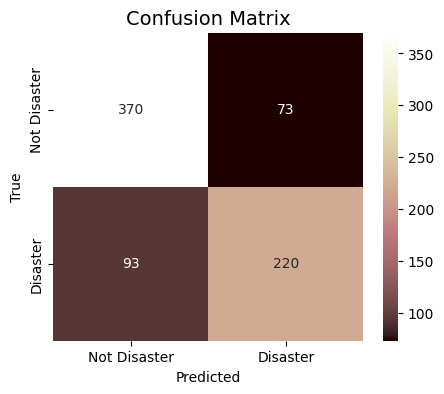

Metrics saved to: model_metrics\NN_Configuration 2.json


In [22]:

display(metrics_report(y2_test, y2_pred))
acc2, prec2, rec2, f12, auc2 = html_metrics(y2_test, y2_pred)
confusion_matrix_heatmap(y2_test, y2_pred)
save_metrics("NN", "Configuration 2", acc2, prec2, rec2, f12, auc2)

## **Configuration 3 – Stemming or Lemmatization**

The third configuration also starts with the basic preprocessing steps from Configuration 1 but incorporates **stemming or lemmatization**. These techniques reduce words to their base or root form in order to normalize different variations of the same word.

* **Stemming** reduces words to a root form by removing suffixes (e.g., *running* → *run*).
* **Lemmatization** converts words to their dictionary form using linguistic rules (e.g., *better* → *good*).

Applying these techniques helps reduce vocabulary size and can improve the model’s ability to generalize by treating related word forms as the same feature.

The performance of the neural network model is then evaluated under each preprocessing configuration using metrics such as **accuracy** and **F1-score**, allowing for a comparison of how different text cleaning strategies influence classification results.


In [23]:
model3 = models.Sequential()

model3.add(layers.Dense(128, activation='relu', input_shape=(x3_train.shape[1],)))
model3.add(layers.Dropout(0.5))

model3.add(layers.Dense(64, activation='relu'))
model3.add(layers.Dropout(0.3))

model3.add(layers.Dense(32, activation='relu'))
model3.add(layers.Dense(16, activation='relu'))
model3.add(layers.Dense(1, activation='sigmoid'))

In [24]:
model3.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy', 'Precision']
)

In [25]:
history3 = model3.fit(
    x3_train,
    y3_train,
    epochs=10,
    batch_size=32,
    validation_data=(x3_val, y3_val))

Epoch 1/10
189/189 [==============================] - 2s 7ms/step - loss: 0.5805 - accuracy: 0.6870 - precision: 0.8003 - val_loss: 0.4463 - val_accuracy: 0.8053 - val_precision: 0.8444
Epoch 2/10
189/189 [==============================] - 1s 6ms/step - loss: 0.3323 - accuracy: 0.8689 - precision: 0.8817 - val_loss: 0.4547 - val_accuracy: 0.8013 - val_precision: 0.8271
Epoch 3/10
189/189 [==============================] - 1s 5ms/step - loss: 0.2027 - accuracy: 0.9272 - precision: 0.9353 - val_loss: 0.5467 - val_accuracy: 0.7947 - val_precision: 0.8029
Epoch 4/10
189/189 [==============================] - 1s 6ms/step - loss: 0.1325 - accuracy: 0.9533 - precision: 0.9565 - val_loss: 0.6333 - val_accuracy: 0.7748 - val_precision: 0.7917
Epoch 5/10
189/189 [==============================] - 1s 6ms/step - loss: 0.0954 - accuracy: 0.9699 - precision: 0.9759 - val_loss: 0.6536 - val_accuracy: 0.7788 - val_precision: 0.7608
Epoch 6/10
189/189 [==============================] - 1s 6ms/step - lo

In [26]:
y3_pred = model3.predict(x3_test)
y3_pred = (y3_pred > 0.5).astype(int)

24/24 [==============================] - 0s 3ms/step


,precision,recall,f1-score,support
0,0.787946,0.796840,0.792368,443.000000
1,0.707792,0.696486,0.702093,313.000000
accuracy,0.755291,0.755291,0.755291,0.755291
macro avg,0.747869,0.746663,0.747231,756.000000
weighted avg,0.754761,0.755291,0.754992,756.000000


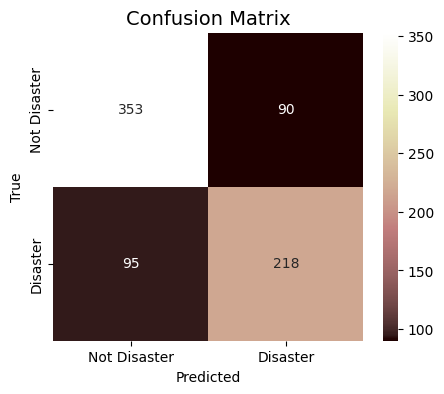

Metrics saved to: model_metrics\NN_Configuration 3.json


In [27]:
display(metrics_report(y3_test, y3_pred))
acc3, prec3, rec3, f13, auc3 = html_metrics(y3_test, y3_pred)
confusion_matrix_heatmap(y3_test, y3_pred)
save_metrics("NN", "Configuration 3", acc3, prec3, rec3, f13, auc3)